Case ID: 003192
Image path: data/003192_img.nii
Mask path:  data/003192_mask.nii
Image shape: (180, 180, 44)
Mask shape:  (180, 180, 44)
Image dtype: float32
Mask dtype:  uint16
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(2.0))
Image intensity range: 0.000 to 1.000
Image mean/std: 0.257 / 0.174
Mask labels and voxel counts:
  label 0: 1,243,321 voxels
  label 1: 62,092 voxels
  label 2: 25,118 voxels
  label 3: 31,219 voxels
  label 4: 13,908 voxels
  label 5: 9,700 voxels
  label 6: 26,239 voxels
  label 7: 9,875 voxels
  label 8: 4,128 voxels
Affine matrix:
[[-9.99761939e-01  3.92968301e-03 -4.29225005e-02  9.56770325e+01]
 [-3.92997125e-03 -9.99992251e-01 -5.75295744e-05  1.04909981e+02]
 [-2.14611981e-02  5.55841580e-05  1.99953938e+00 -6.16926041e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


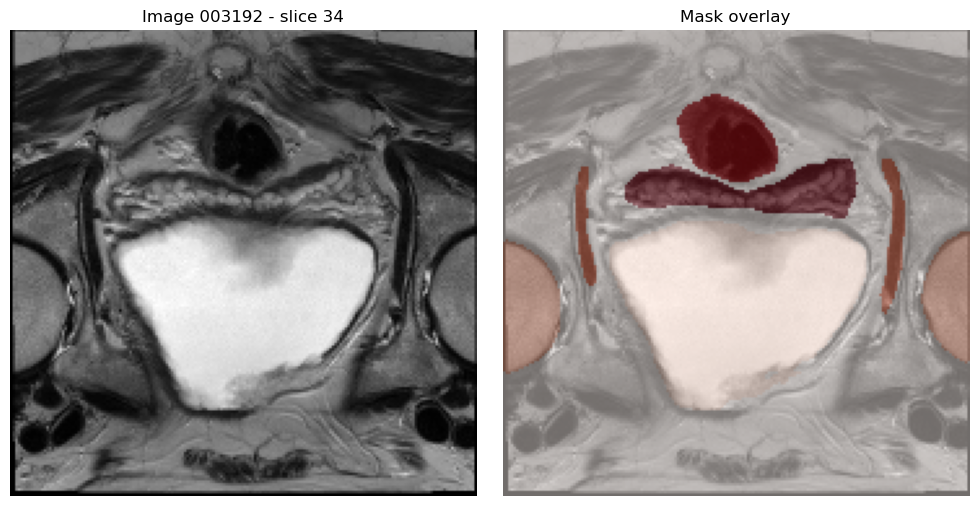

In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np

try:
    import nibabel as nib
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install nibabel first with: %pip install nibabel") from exc

data_dir = Path("data")

image_paths = {p.stem.replace("_img", ""): p for p in data_dir.glob("*_img.nii")}
mask_paths = {p.stem.replace("_mask", ""): p for p in data_dir.glob("*_mask.nii")}
case_ids = sorted(image_paths.keys() & mask_paths.keys())

if not case_ids:
    raise FileNotFoundError("No matching *_img.nii and *_mask.nii pairs found in data/")

case_id = random.choice(case_ids)
image_nii = nib.load(image_paths[case_id])
mask_nii = nib.load(mask_paths[case_id])
image = image_nii.get_fdata()
mask = mask_nii.get_fdata()

mask_labels, mask_counts = np.unique(mask, return_counts=True)
print(f"Case ID: {case_id}")
print(f"Image path: {image_paths[case_id]}")
print(f"Mask path:  {mask_paths[case_id]}")
print(f"Image shape: {image.shape}")
print(f"Mask shape:  {mask.shape}")
print(f"Image dtype: {image_nii.get_data_dtype()}")
print(f"Mask dtype:  {mask_nii.get_data_dtype()}")
print(f"Voxel spacing: {image_nii.header.get_zooms()[: image.ndim]}")
print(f"Image intensity range: {np.nanmin(image):.3f} to {np.nanmax(image):.3f}")
print(f"Image mean/std: {np.nanmean(image):.3f} / {np.nanstd(image):.3f}")
print("Mask labels and voxel counts:")
for label, count in zip(mask_labels, mask_counts):
    print(f"  label {label:g}: {count:,} voxels")
print("Affine matrix:")
print(image_nii.affine)

if image.ndim != 3 or mask.ndim != 3:
    raise ValueError(f"Expected 3D NIfTI volumes, got image={image.shape}, mask={mask.shape}")

mask_area_by_slice = mask.sum(axis=(0, 1))
slice_idx = int(mask_area_by_slice.argmax()) if mask_area_by_slice.max() > 0 else image.shape[2] // 2

image_slice = np.rot90(image[:, :, slice_idx])
mask_slice = np.rot90(mask[:, :, slice_idx])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_slice, cmap="gray")
axes[0].set_title(f"Image {case_id} - slice {slice_idx}")
axes[0].axis("off")

axes[1].imshow(image_slice, cmap="gray")
axes[1].imshow(mask_slice, cmap="Reds", alpha=0.45)
axes[1].set_title("Mask overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [5]:
from collections import Counter
from pathlib import Path

try:
    import nibabel as nib
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install nibabel first with: %pip install nibabel") from exc

data_dir = Path("data")

image_paths = {p.stem.replace("_img", ""): p for p in data_dir.glob("*_img.nii")}
mask_paths = {p.stem.replace("_mask", ""): p for p in data_dir.glob("*_mask.nii")}
case_ids = sorted(image_paths.keys() & mask_paths.keys())

if not case_ids:
    raise FileNotFoundError("No matching *_img.nii and *_mask.nii pairs found in data/")

image_shape_counts = Counter()
mask_shape_counts = Counter()
pair_shape_counts = Counter()
image_shapes = []
mask_shapes = []
mismatched_cases = []

for case_id in case_ids:
    image_shape = nib.load(image_paths[case_id]).shape
    mask_shape = nib.load(mask_paths[case_id]).shape

    image_shape_counts[image_shape] += 1
    mask_shape_counts[mask_shape] += 1
    pair_shape_counts[(image_shape, mask_shape)] += 1
    image_shapes.append(image_shape)
    mask_shapes.append(mask_shape)

    if image_shape != mask_shape:
        mismatched_cases.append((case_id, image_shape, mask_shape))

print(f"Total paired cases: {len(case_ids)}")

print("\nUnique image shapes:")
for shape, count in sorted(image_shape_counts.items()):
    print(f"  {shape}: {count} cases")

print("\nUnique mask shapes:")
for shape, count in sorted(mask_shape_counts.items()):
    print(f"  {shape}: {count} cases")

print("\nUnique image/mask shape pairs:")
for (image_shape, mask_shape), count in sorted(pair_shape_counts.items()):
    print(f"  image {image_shape}, mask {mask_shape}: {count} cases")

image_shapes_array = np.array(image_shapes)
mask_shapes_array = np.array(mask_shapes)
image_voxels = np.prod(image_shapes_array, axis=1)
mask_voxels = np.prod(mask_shapes_array, axis=1)

print("\nImage size statistics per dimension:")
print(f"  minimum shape: {image_shapes_array.min(axis=0)}")
print(f"  maximum shape: {image_shapes_array.max(axis=0)}")
print(f"  average shape: {image_shapes_array.mean(axis=0)}")
print(f"  variance:      {image_shapes_array.var(axis=0)}")
print(f"  std deviation: {image_shapes_array.std(axis=0)}")
print(f"  minimum voxels: {image_voxels.min()}")
print(f"  maximum voxels: {image_voxels.max()}")
print(f"  average voxels: {image_voxels.mean():.2f}")
print(f"  voxel variance: {image_voxels.var():.2f}")
print(f"  voxel std deviation: {image_voxels.std():.2f}")

print("\nMask size statistics per dimension:")
print(f"  minimum shape: {mask_shapes_array.min(axis=0)}")
print(f"  maximum shape: {mask_shapes_array.max(axis=0)}")
print(f"  average shape: {mask_shapes_array.mean(axis=0)}")
print(f"  variance:      {mask_shapes_array.var(axis=0)}")
print(f"  std deviation: {mask_shapes_array.std(axis=0)}")
print(f"  minimum voxels: {mask_voxels.min()}")
print(f"  maximum voxels: {mask_voxels.max()}")
print(f"  average voxels: {mask_voxels.mean():.2f}")
print(f"  voxel variance: {mask_voxels.var():.2f}")
print(f"  voxel std deviation: {mask_voxels.std():.2f}")

print(f"\nMismatched image/mask shape cases: {len(mismatched_cases)}")
for case_id, image_shape, mask_shape in mismatched_cases[:20]:
    print(f"  {case_id}: image {image_shape}, mask {mask_shape}")


Total paired cases: 589

Unique image shapes:
  (120, 120, 39): 1 cases
  (120, 120, 47): 1 cases
  (120, 120, 65): 1 cases
  (139, 139, 53): 1 cases
  (139, 139, 57): 1 cases
  (139, 139, 60): 2 cases
  (139, 139, 63): 1 cases
  (139, 139, 65): 1 cases
  (139, 139, 70): 2 cases
  (139, 139, 73): 5 cases
  (139, 139, 75): 3 cases
  (139, 139, 77): 7 cases
  (139, 139, 80): 3 cases
  (139, 139, 85): 1 cases
  (140, 140, 39): 1 cases
  (140, 140, 49): 1 cases
  (140, 140, 50): 1 cases
  (150, 150, 40): 1 cases
  (150, 150, 47): 1 cases
  (150, 150, 49): 1 cases
  (150, 150, 50): 1 cases
  (150, 150, 52): 2 cases
  (150, 150, 53): 2 cases
  (150, 150, 58): 6 cases
  (159, 159, 77): 1 cases
  (159, 159, 83): 1 cases
  (160, 160, 37): 1 cases
  (160, 160, 39): 1 cases
  (160, 160, 41): 1 cases
  (160, 160, 43): 1 cases
  (160, 160, 44): 2 cases
  (160, 160, 46): 20 cases
  (160, 160, 47): 13 cases
  (160, 160, 49): 5 cases
  (160, 160, 50): 7 cases
  (160, 160, 52): 1 cases
  (160, 160, 55)

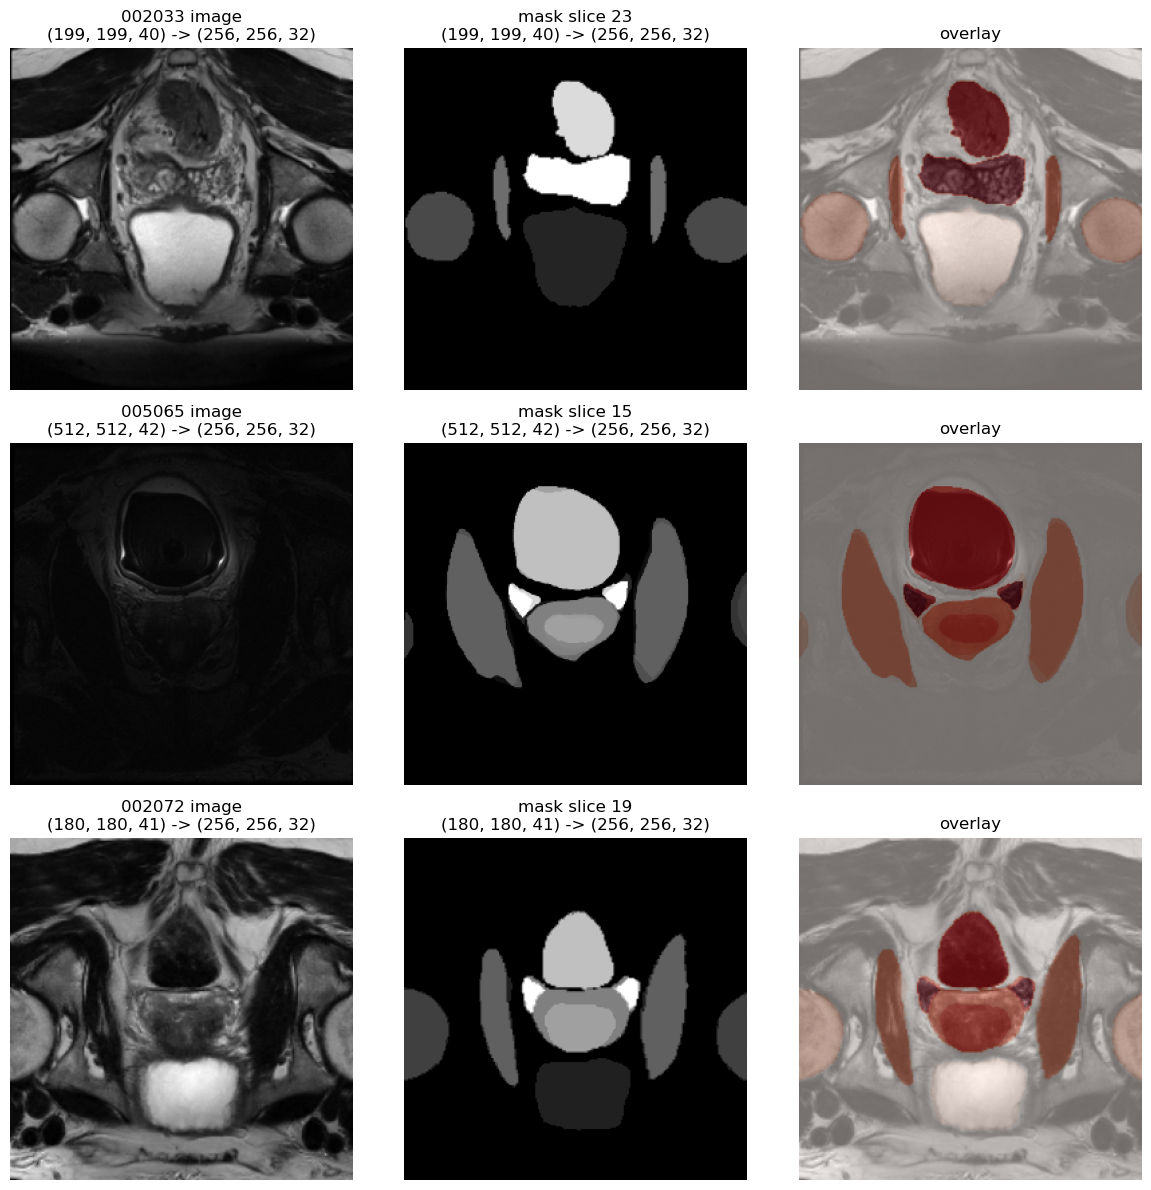

In [6]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

from resize import resize_image_mask

data_dir = Path("data")
target_shape = (256, 256, 32)

image_paths = {p.stem.replace("_img", ""): p for p in data_dir.glob("*_img.nii")}
mask_paths = {p.stem.replace("_mask", ""): p for p in data_dir.glob("*_mask.nii")}
case_ids = sorted(image_paths.keys() & mask_paths.keys())

sample_ids = random.sample(case_ids, k=min(3, len(case_ids)))
fig, axes = plt.subplots(len(sample_ids), 3, figsize=(12, 4 * len(sample_ids)))

if len(sample_ids) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, case_id in enumerate(sample_ids):
    image = nib.load(image_paths[case_id]).get_fdata(dtype=np.float32)
    mask = np.asanyarray(nib.load(mask_paths[case_id]).dataobj)

    resized_image, resized_mask = resize_image_mask(image, mask, dimensions=target_shape)

    mask_area_by_slice = resized_mask.sum(axis=(0, 1))
    slice_idx = int(mask_area_by_slice.argmax()) if mask_area_by_slice.max() > 0 else target_shape[2] // 2

    image_slice = np.rot90(resized_image[:, :, slice_idx])
    mask_slice = np.rot90(resized_mask[:, :, slice_idx])

    axes[row, 0].imshow(image_slice, cmap="gray")
    axes[row, 0].set_title(f"{case_id} image\n{image.shape} -> {resized_image.shape}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask_slice, cmap="gray")
    axes[row, 1].set_title(f"mask slice {slice_idx}\n{mask.shape} -> {resized_mask.shape}")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(image_slice, cmap="gray")
    axes[row, 2].imshow(mask_slice, cmap="Reds", alpha=0.45)
    axes[row, 2].set_title("overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()
